In [16]:
import cv2
import mediapipe as mp
import numpy as np
import joblib

# ── Load model & encoder ──────────────────────────────────────
xgb_model = joblib.load(r"C:\Users\ADITYA PATEL\OneDrive\Desktop\yoga_project\xgb_model.pkl")
le        = joblib.load(r"C:\Users\ADITYA PATEL\OneDrive\Desktop\yoga_project\label_encoder.pkl")

# ── MediaPipe setup ───────────────────────────────────────────
mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ── Ideal angles per pose ─────────────────────────────────────
IDEAL_ANGLES = {
    "Downdog":  [170, 170, 170, 170,  90,  90, 170, 170,  90,  90],
    "Goddess":  [170, 170,  90,  90, 120, 120,  90,  90,  90,  90],
    "Plank":    [170, 170, 180, 180, 180, 180, 170, 170,  90,  90],
    "Tree":     [170, 170, 170, 170, 170, 170, 170,  45, 100,  90],
    "Warrior2": [170, 170,  90,  90, 170, 120,  90, 170,  90,  90],
}

ANGLE_NAMES = [
    "Left Elbow",    "Right Elbow",
    "Left Shoulder", "Right Shoulder",
    "Left Hip",      "Right Hip",
    "Left Knee",     "Right Knee",
    "Left Ankle",    "Right Ankle"
]

TOLERANCE = 25  # degrees allowed deviation

# ── Helper functions ──────────────────────────────────────────
def compute_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


def get_features(landmarks):
    kp = []
    for lm in landmarks:
        kp.extend([lm.x, lm.y, lm.z, lm.visibility])

    def get_xy(idx):
        return [kp[idx * 4], kp[idx * 4 + 1]]

    LS, RS = 11, 12
    LE, RE = 13, 14
    LW, RW = 15, 16
    LH, RH = 23, 24
    LK, RK = 25, 26
    LA, RA = 27, 28

    angles = [
        compute_angle(get_xy(LS), get_xy(LE), get_xy(LW)),
        compute_angle(get_xy(RS), get_xy(RE), get_xy(RW)),
        compute_angle(get_xy(LE), get_xy(LS), get_xy(LH)),
        compute_angle(get_xy(RE), get_xy(RS), get_xy(RH)),
        compute_angle(get_xy(LS), get_xy(LH), get_xy(LK)),
        compute_angle(get_xy(RS), get_xy(RH), get_xy(RK)),
        compute_angle(get_xy(LH), get_xy(LK), get_xy(LA)),
        compute_angle(get_xy(RH), get_xy(RK), get_xy(RA)),
        compute_angle(get_xy(LK), get_xy(LA), get_xy(LH)),
        compute_angle(get_xy(RK), get_xy(RA), get_xy(RH)),
    ]
    return kp + angles, angles


def get_feedback(pose_name, angles):
    ideal  = IDEAL_ANGLES[pose_name]
    issues = []
    for i, (actual, target) in enumerate(zip(angles, ideal)):
        if abs(actual - target) > TOLERANCE:
            issues.append((ANGLE_NAMES[i], i))
    return issues


def draw_feedback(frame, pose_name, confidence, issues, angles):
    h, w, _ = frame.shape

    # ── Top bar: pose name + confidence ───────────────────────
    cv2.rectangle(frame, (0, 0), (w, 60), (0, 0, 0), -1)
    color = (0, 255, 0) if not issues else (0, 165, 255)
    cv2.putText(frame, f"Pose: {pose_name}  ({confidence:.0f}%)",
                (10, 42), cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 2)

    # ── Feedback panel ────────────────────────────────────────
    if not issues:
        cv2.rectangle(frame, (0, 65), (380, 100), (0, 100, 0), -1)
        cv2.putText(frame, "  CORRECT POSE!  Well done!",
                    (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)
    else:
        cv2.rectangle(frame, (0, 65), (w, 100), (20, 20, 120), -1)
        cv2.putText(frame, "  Adjust these joints:",
                    (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (100, 180, 255), 2)

        ideal = IDEAL_ANGLES[pose_name]

        for i, (joint_name, idx) in enumerate(issues):
            actual = angles[idx]
            target = ideal[idx]
            diff   = actual - target

            if diff > 0:
                direction = f"decrease by {abs(diff):.0f} deg"
                arrow     = "v"   # down arrow
                col       = (0, 80, 255)
            else:
                direction = f"increase by {abs(diff):.0f} deg"
                arrow     = "^"   # up arrow
                col       = (0, 200, 255)

            text = f"  {arrow} {joint_name}: {actual:.0f} deg  (need {target} deg, {direction})"
            cv2.putText(frame, text,
                        (10, 130 + i * 35),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)

    return frame


# ── Main webcam loop ──────────────────────────────────────────
cap = cv2.VideoCapture(0)
cv2.namedWindow("Yoga Pose Detection", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Yoga Pose Detection", 900, 650)

print("✅ Webcam started! Press Q to quit.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame   = cv2.flip(frame, 1)
    rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose.process(rgb)

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS
        )

        features, angles = get_features(results.pose_landmarks.landmark)
        features  = np.array(features).reshape(1, -1)

        pred_idx   = xgb_model.predict(features)[0]
        pred_proba = xgb_model.predict_proba(features)[0]
        pose_name  = le.inverse_transform([pred_idx])[0]
        confidence = pred_proba[pred_idx] * 100

        issues = get_feedback(pose_name, angles)
        frame  = draw_feedback(frame, pose_name, confidence, issues, angles)

    else:
        cv2.rectangle(frame, (0, 0), (400, 60), (0, 0, 0), -1)
        cv2.putText(frame, "No person detected",
                    (10, 42), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    cv2.imshow("Yoga Pose Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("✅ Done.")

✅ Webcam started! Press Q to quit.
✅ Done.


   YOGA POSE DETECTION — ALL METRICS

  Accuracy          : 97.96%
  Macro Precision   : 98.01%
  Macro Recall      : 97.95%
  Macro F1-Score    : 97.96%
  MSE               : 0.0765
  RMSE              : 0.2766
  MAE               : 0.0357
  R² Score          : 0.9616

  Per Class F1-Score:
  Pose               F1    Precision     Recall
  ---------------------------------------------
  Downdog        100.0%      100.0%     100.0%
  Goddess         96.1%       97.4%      94.9%
  Plank           98.7%      100.0%      97.4%
  Tree            97.6%       95.2%     100.0%
  Warrior2        97.4%       97.4%      97.4%


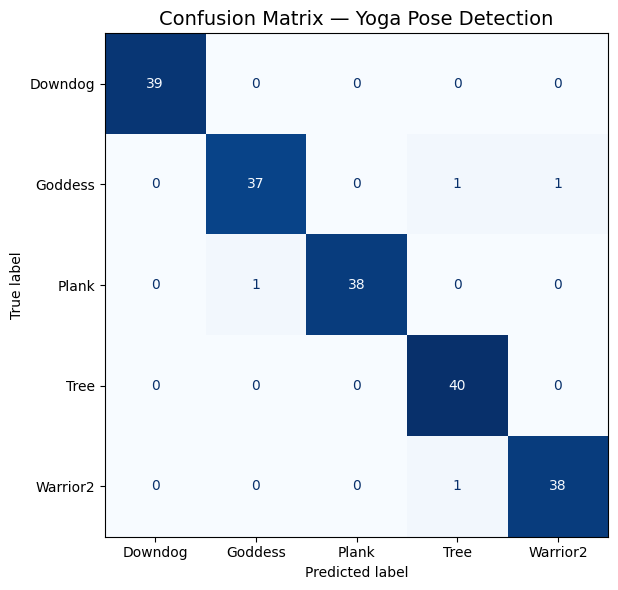


✅ Confusion matrix saved to your yoga_project folder!


In [15]:
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, mean_squared_error,
                              mean_absolute_error, r2_score,
                              ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

# ── Core Metrics ──────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred) * 100
mse       = mean_squared_error(y_test, y_pred)
rmse      = np.sqrt(mse)
mae       = mean_absolute_error(y_test, y_pred)
r2        = r2_score(y_test, y_pred)

report    = classification_report(y_test, y_pred, 
                                   target_names=le.classes_, 
                                   output_dict=True)

macro_p   = report['macro avg']['precision']  * 100
macro_r   = report['macro avg']['recall']     * 100
macro_f1  = report['macro avg']['f1-score']   * 100

print("=" * 50)
print("   YOGA POSE DETECTION — ALL METRICS")
print("=" * 50)
print(f"\n  Accuracy          : {accuracy:.2f}%")
print(f"  Macro Precision   : {macro_p:.2f}%")
print(f"  Macro Recall      : {macro_r:.2f}%")
print(f"  Macro F1-Score    : {macro_f1:.2f}%")
print(f"  MSE               : {mse:.4f}")
print(f"  RMSE              : {rmse:.4f}")
print(f"  MAE               : {mae:.4f}")
print(f"  R² Score          : {r2:.4f}")

print("\n  Per Class F1-Score:")
print(f"  {'Pose':<12} {'F1':>8} {'Precision':>12} {'Recall':>10}")
print("  " + "-" * 45)
for cls in le.classes_:
    r = report[cls]
    print(f"  {cls:<12} {r['f1-score']*100:>7.1f}%"
          f" {r['precision']*100:>10.1f}%"
          f" {r['recall']*100:>9.1f}%")

# ── Confusion Matrix ──────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Yoga Pose Detection", fontsize=14)
plt.tight_layout()
plt.savefig(r"C:\Users\ADITYA PATEL\OneDrive\Desktop\yoga_project\confusion_matrix.png", dpi=150)
plt.show()
print("\n✅ Confusion matrix saved to your yoga_project folder!")